# 😴 Sleep Disorder Prediction: ML for Workplace Health & Wellbeing

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting sleep disorders from lifestyle and health metrics to support workplace wellness and preventive health  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting sleep disorders (Insomnia, Sleep Apnea) using lifestyle factors (physical activity, stress, occupation), health metrics (BMI, blood pressure, heart rate), and sleep quality indicators. The model supports **workplace wellness programs**, **occupational health screening**, and **chronic disease prevention**.

### Government Policy Context
- **Safe Work Australia** — WHS fatigue management, shift worker safety, psychosocial hazards
- **Department of Health** — Sleep Health Foundation partnership, chronic disease prevention
- **AIHW** — Sleep disorder prevalence, burden of disease from inadequate sleep
- **Comcare** — Commonwealth workplace health, mental health & wellbeing strategy
- **Fair Work Commission** — Working hours, fatigue risk management for shift workers

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Sleep Apnea risk | Refer for sleep study (polysomnography), CPAP assessment | GP + sleep physician |
| Insomnia risk | CBT-i referral, sleep hygiene education, stress management | GP + psychologist |
| No disorder (confident) | Maintain healthy sleep habits, annual wellness check | Workplace wellness |
| No disorder (risk factors) | Fatigue risk management, workload review | WHS officer |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/uom190346a/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv

Using: /kaggle/input/datasets/uom190346a/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv
Loaded: 374 rows x 13 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Person ID                      | int64      | unique=  374 | nulls=  0 | eg: 1
   1. Gender                         | object     | unique=    2 | nulls=  0 | eg: Male
   2. Age                            | int64      | unique=   31 | nulls=  0 | eg: 27
   3. Occupation                     | object     | unique=   11 | nulls=  0 | eg: Software Engineer
   4. Sleep Duration                 | float64    | unique=   27 | nulls=  0 | eg: 6.1
   5. Quality of Sleep               | int64      | unique=    6 | nulls=  0 | eg: 6
   6. Physical Activity Level        | int64      | unique=   16 | nulls=  0 | eg: 42
   7. Stress Level                   | int64      | unique=    6 | nulls=  0 | eg: 6
   8. BMI Category                   | object     | unique=    4 | nulls=  0 | eg: Overweight
   9. Blood Pressure                 | object     | unique=   25 | nulls=  0 | eg: 126/83
  10. Heart Rate                     | int64      | unique=   19 | nulls=  0 | eg: 77
  11. Daily 

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Target Variable Analysis

In [4]:
# Known target: 'Sleep Disorder'
target_candidates = ['Sleep Disorder', 'sleep_disorder', 'SleepDisorder', 'disorder',
                     'target', 'Target', 'class', 'Class', 'label']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

# Fill NaN in target (None = no disorder)
df[target_col] = df[target_col].fillna('None')

print(f"\nRaw distribution:")
print(df[target_col].value_counts())

# Encode target
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))
target_labels = list(le_target.classes_)
n_classes = len(target_labels)

# Remap to sequential if needed
unique_y = np.sort(df[target_col].unique())
if not np.array_equal(unique_y, np.arange(len(unique_y))):
    class_map = {old: new for new, old in enumerate(unique_y)}
    df[target_col] = df[target_col].map(class_map)

print(f"\nEncoded labels: {dict(zip(range(n_classes), target_labels))}")
print(f"\nFinal distribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2


Found target: 'Sleep Disorder'

Raw distribution:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Encoded labels: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

Final distribution:
Sleep Disorder
0     77
1    219
2     78
Name: count, dtype: int64


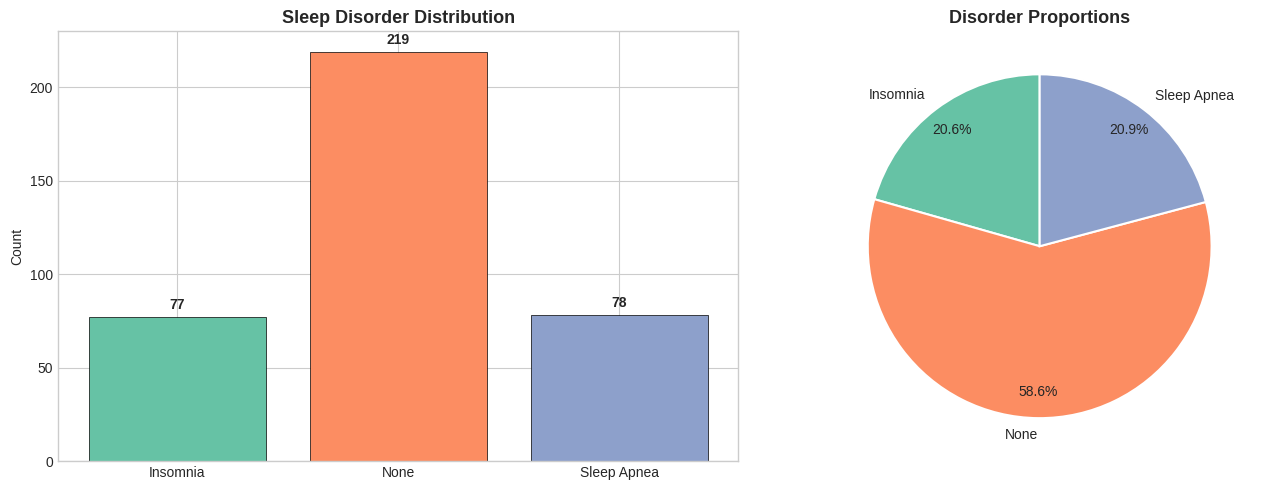

AU context: ~1.5M Australians have sleep apnea, ~1M have chronic insomnia (Sleep Health Foundation).
Inadequate sleep costs Australian economy ~$66.3B/year (Deloitte/Sleep Health Foundation).
Fatigue-related workplace incidents are a major WHS concern for Safe Work Australia.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
colors = sns.color_palette('Set2', n_colors=n_classes)
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(target_labels, fontsize=10)
axes[0].set_title('Sleep Disorder Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=target_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Disorder Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~1.5M Australians have sleep apnea, ~1M have chronic insomnia (Sleep Health Foundation).")
print("Inadequate sleep costs Australian economy ~$66.3B/year (Deloitte/Sleep Health Foundation).")
print("Fatigue-related workplace incidents are a major WHS concern for Safe Work Australia.")


## 3. Exploratory Data Analysis

Key questions for workplace health:
- Which occupations have highest sleep disorder rates?
- Does physical activity protect against sleep disorders?
- How do stress levels correlate with insomnia?
- Is BMI a strong predictor of sleep apnea?


Numeric features (7): ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


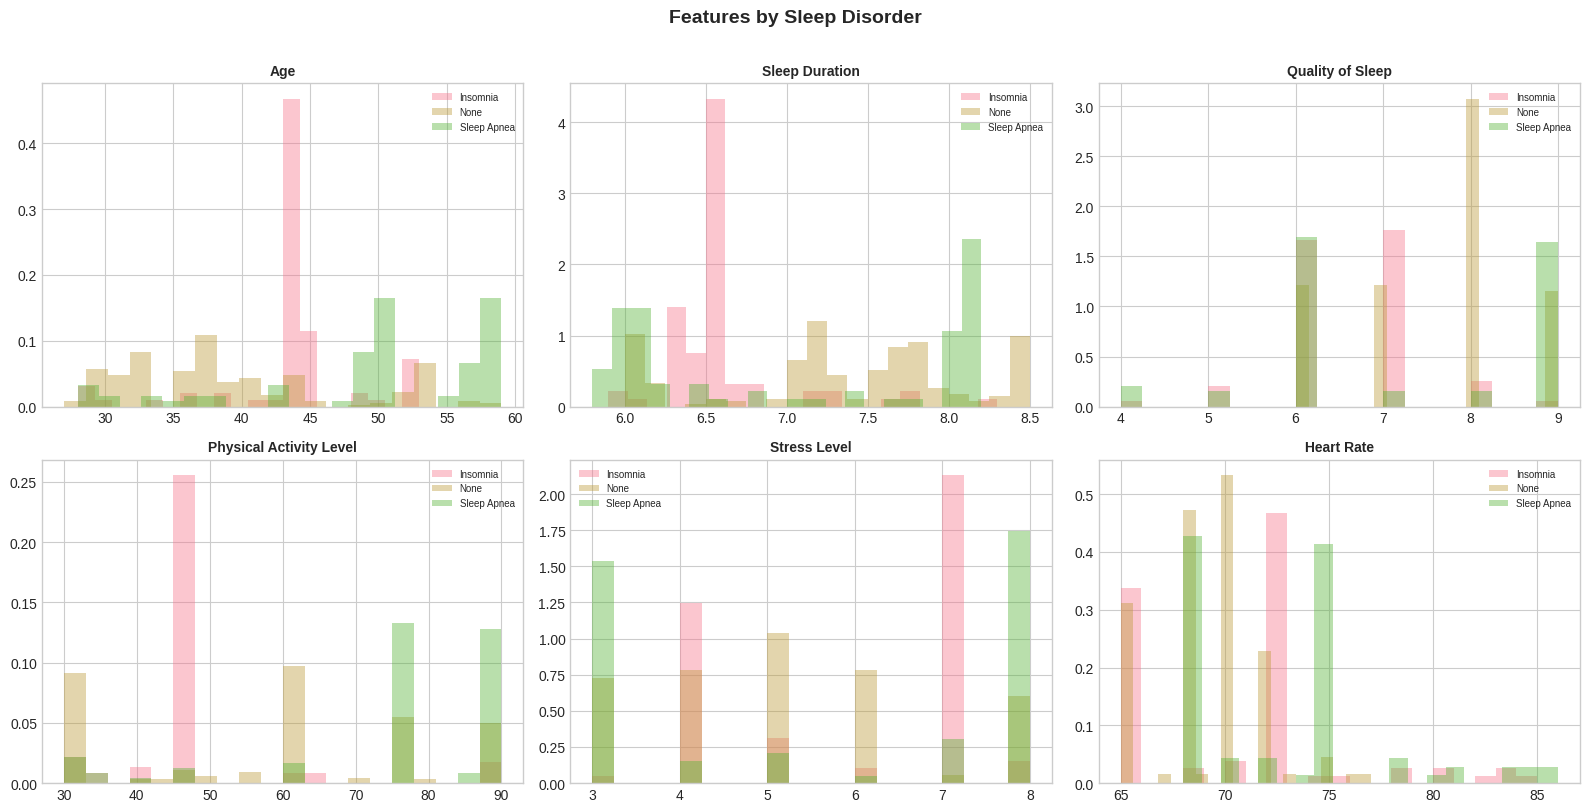

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['person id', 'id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for cls_val in sorted(df[target_col].unique()):
            subset = df[df[target_col] == cls_val][col].dropna()
            lbl = target_labels[cls_val] if cls_val < len(target_labels) else f'Class {cls_val}'
            if len(subset) > 0:
                axes[i].hist(subset, bins=20, alpha=0.4, label=lbl, density=True)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Features by Sleep Disorder', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['Gender', 'Occupation', 'BMI Category']


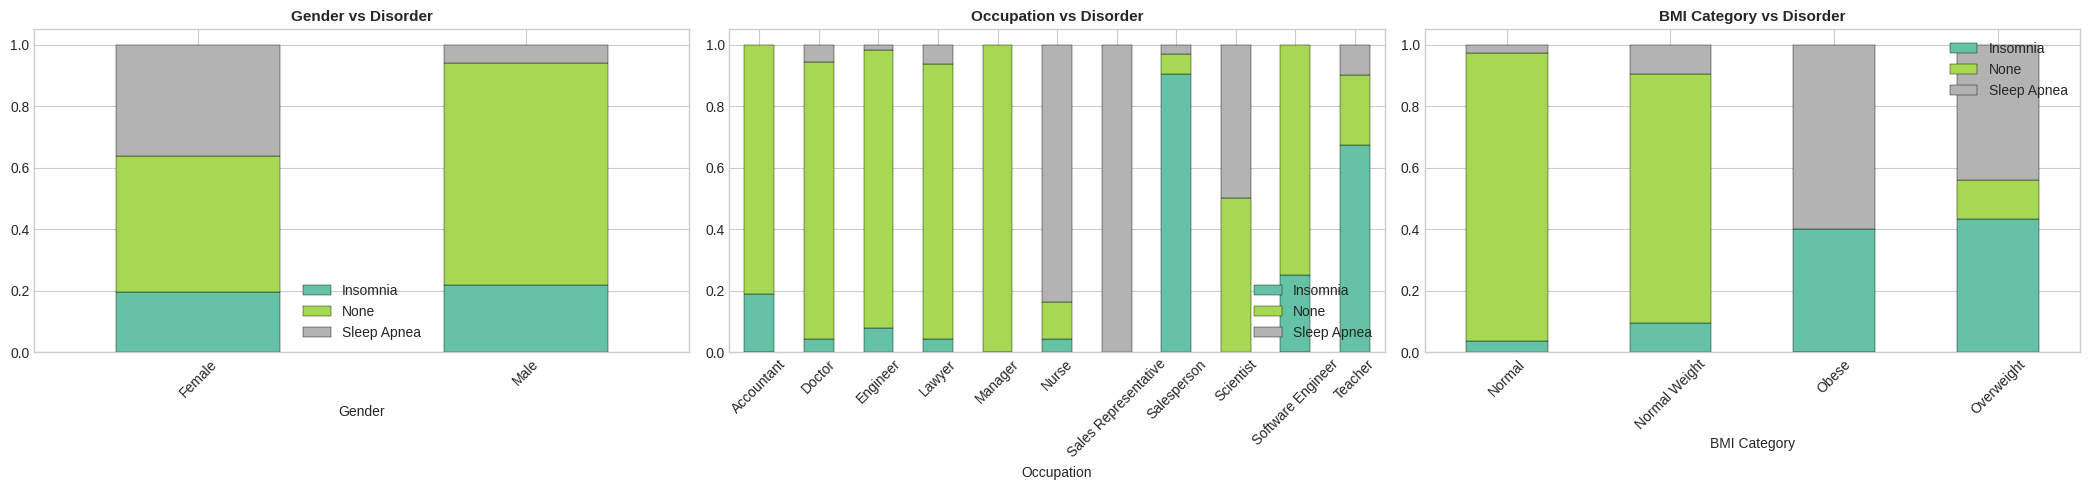

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'id' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = max(1, (len(plot_cats) + n_cols_p - 1) // n_cols_p)
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.columns = target_labels[:len(ct.columns)]
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Disorder', fontsize=11, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


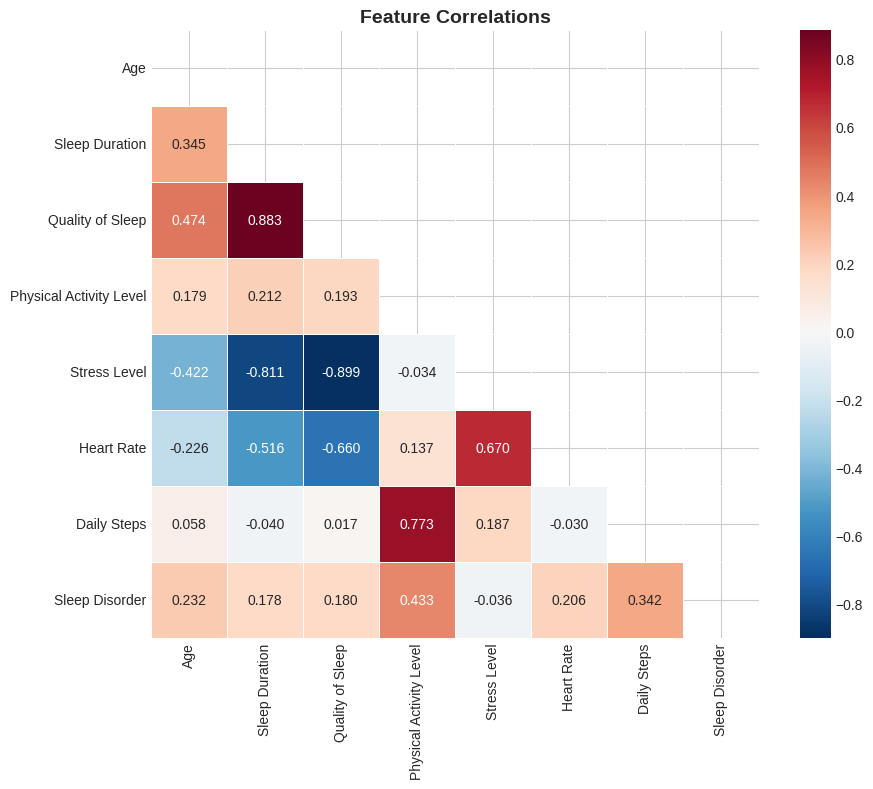

In [8]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['person id', 'id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)
    print(f"Dropped: {drop_cols}")

# Handle Blood Pressure column (often stored as "130/85" string)
bp_col = [c for c in df_model.columns if 'blood pressure' in c.lower() or 'bloodpressure' in c.lower()]
if bp_col and df_model[bp_col[0]].dtype == 'object':
    bp = df_model[bp_col[0]].str.split('/', expand=True)
    if bp.shape[1] == 2:
        df_model['systolic_bp'] = pd.to_numeric(bp[0], errors='coerce')
        df_model['diastolic_bp'] = pd.to_numeric(bp[1], errors='coerce')
        df_model.drop(columns=bp_col, inplace=True)
        print(f"Split '{bp_col[0]}' into systolic_bp and diastolic_bp")

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target classes: {np.unique(y)}")


Dropped: ['Person ID']
Split 'Blood Pressure' into systolic_bp and diastolic_bp
  Encoded 'Gender': 2 classes
  Encoded 'Occupation': 11 classes
  Encoded 'BMI Category': 4 classes

Feature matrix: (374, 12)
Target classes: [0 1 2]


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Sleep efficiency (duration * quality proxy)
dur_cols = [c for c in feature_names if 'duration' in c.lower() or 'sleep' in c.lower()]
qual_cols = [c for c in feature_names if 'quality' in c.lower()]
if dur_cols and qual_cols:
    X['sleep_efficiency'] = X[dur_cols[0]] * X[qual_cols[0]]
    composites_added.append('sleep_efficiency')
    print(f"Created 'sleep_efficiency' ({dur_cols[0]} x {qual_cols[0]})")

# Stress-activity ratio
stress_cols = [c for c in feature_names if 'stress' in c.lower()]
activity_cols = [c for c in feature_names if 'activity' in c.lower() or 'physical' in c.lower()]
if stress_cols and activity_cols:
    X['stress_activity_ratio'] = X[stress_cols[0]] / (X[activity_cols[0]] + 1)
    composites_added.append('stress_activity_ratio')
    print("Created 'stress_activity_ratio'")

# High BP flag
if 'systolic_bp' in X.columns:
    X['high_bp'] = (X['systolic_bp'] >= 130).astype(int)
    composites_added.append('high_bp')
    print("Created 'high_bp' (systolic >= 130)")

# Sedentary flag
steps_cols = [c for c in feature_names if 'steps' in c.lower()]
if steps_cols:
    X['sedentary'] = (X[steps_cols[0]] < 5000).astype(int)
    composites_added.append('sedentary')
    print("Created 'sedentary' (<5000 steps)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'sleep_efficiency' (Sleep Duration x Quality of Sleep)
Created 'stress_activity_ratio'
Created 'high_bp' (systolic >= 130)
Created 'sedentary' (<5000 steps)

Engineered: 4
Final feature count: 16


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42,
                                               multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_val, y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'kappa_mean': np.mean(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9360  F1(w)=0.9360  Kappa=0.8876
  Fold 2: Acc=0.8960  F1(w)=0.8960  Kappa=0.8174
  Fold 3: Acc=0.8790  F1(w)=0.8793  Kappa=0.7884
  -- Acc: 0.9037  F1: 0.9038  Kappa: 0.8311  Time: 1.02s

Training: Random Forest
  Fold 1: Acc=0.9200  F1(w)=0.9184  Kappa=0.8572
  Fold 2: Acc=0.9040  F1(w)=0.9045  Kappa=0.8323
  Fold 3: Acc=0.8871  F1(w)=0.8877  Kappa=0.8016
  -- Acc: 0.9037  F1: 0.9035  Kappa: 0.8304  Time: 0.65s

Training: XGBoost
  Fold 1: Acc=0.9200  F1(w)=0.9184  Kappa=0.8572
  Fold 2: Acc=0.9040  F1(w)=0.9045  Kappa=0.8323
  Fold 3: Acc=0.8952  F1(w)=0.8944  Kappa=0.8137
  -- Acc: 0.9064  F1: 0.9058  Kappa: 0.8344  Time: 0.41s

Training: LightGBM
  Fold 1: Acc=0.9200  F1(w)=0.9184  Kappa=0.8572
  Fold 2: Acc=0.8960  F1(w)=0.8967  Kappa=0.8183
  Fold 3: Acc=0.8871  F1(w)=0.8868  Kappa=0.8004
  -- Acc: 0.9010  F1: 0.9006  Kappa: 0.8253  Time: 0.35s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'Kappa': f"{res['kappa_mean']:.4f}",
        'Time': f"{res['time']:.2f}s",
        'sort_val': res['f1_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', 'Kappa', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy     F1 (weighted)  Kappa  Time
            XGBoost 0.9064 +/- 0.0103 0.9058 +/- 0.0098 0.8344 0.41s
Logistic Regression 0.9037 +/- 0.0239 0.9038 +/- 0.0238 0.8311 1.02s
      Random Forest 0.9037 +/- 0.0134 0.9035 +/- 0.0126 0.8304 0.65s
           LightGBM 0.9010 +/- 0.0139 0.9006 +/- 0.0132 0.8253 0.35s

Best model: XGBoost


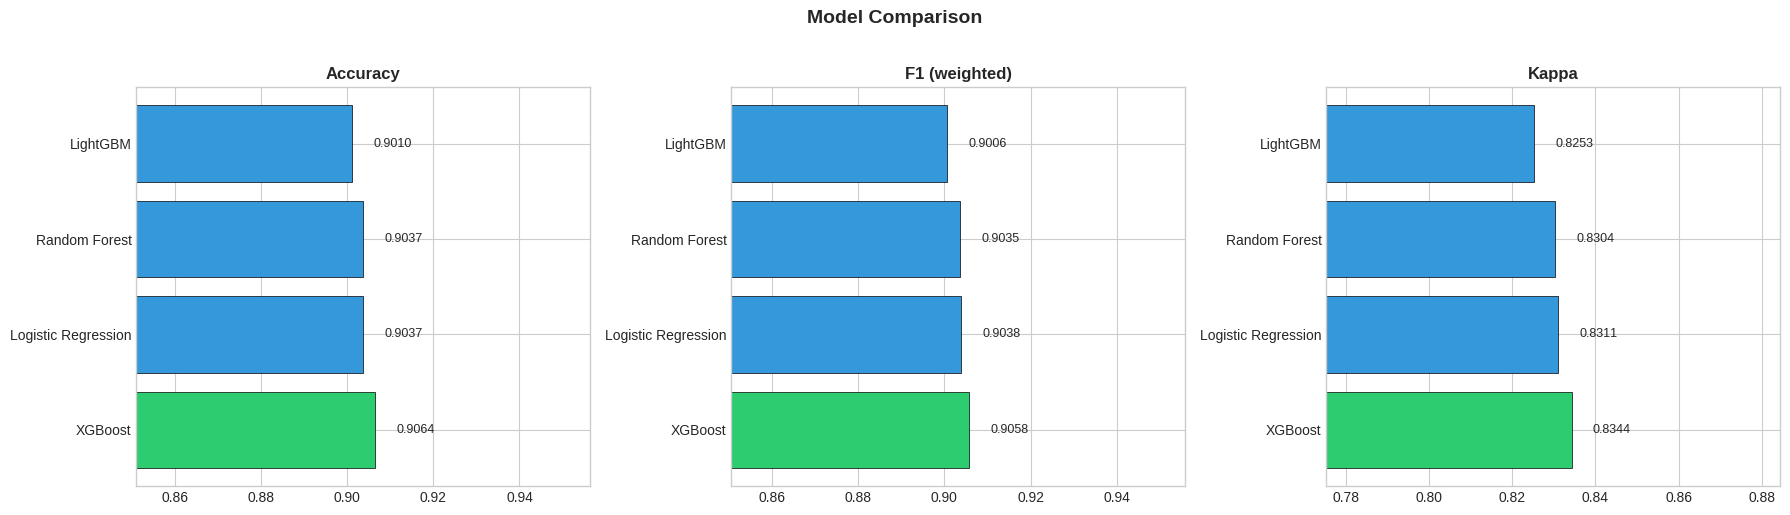

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'kappa_mean'], ['Accuracy', 'F1 (weighted)', 'Kappa']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.05)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis

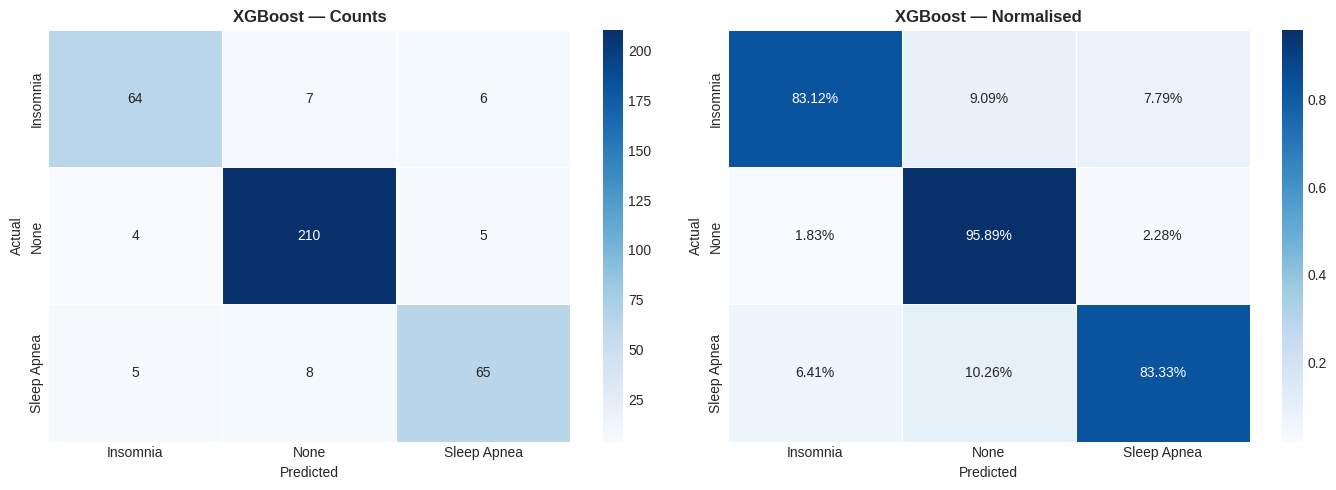


              precision    recall  f1-score   support

    Insomnia       0.88      0.83      0.85        77
        None       0.93      0.96      0.95       219
 Sleep Apnea       0.86      0.83      0.84        78

    accuracy                           0.91       374
   macro avg       0.89      0.87      0.88       374
weighted avg       0.91      0.91      0.91       374



In [15]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")


## 8. Feature Importance & Policy Insights

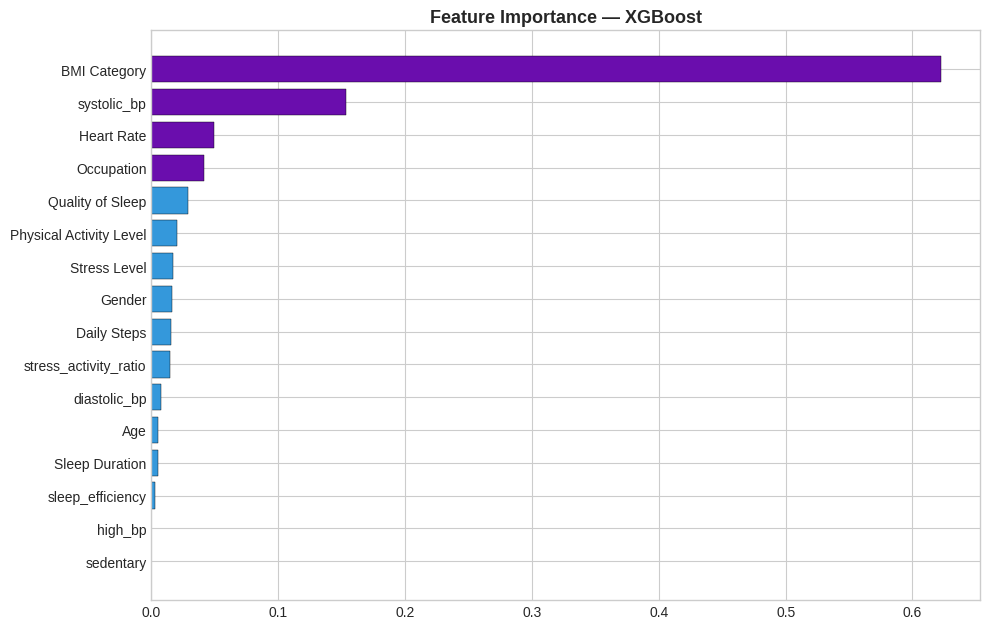

TOP 5 SLEEP DISORDER PREDICTORS
  BMI Category                    0.6221
  systolic_bp                     0.1532
  Heart Rate                      0.0491
  Occupation                      0.0415
  Quality of Sleep                0.0288

Policy insight: Stress, BMI, and physical activity are modifiable risk factors.
Occupation-based interventions can target high-risk worker groups.


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#6a0dad' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 SLEEP DISORDER PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")
    print("\nPolicy insight: Stress, BMI, and physical activity are modifiable risk factors.")
    print("Occupation-based interventions can target high-risk worker groups.")


## 9. Deployment Readiness & Production Considerations

In [17]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Disorder classes:     {n_classes} ({target_labels})")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.70': best_res['accuracy_mean'] > 0.70,
    'F1 > 0.70': best_res['f1_mean'] > 0.70,
    'Kappa > 0.50': best_res['kappa_mean'] > 0.50,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    XGBoost
  Accuracy:             0.9064
  F1 (weighted):        0.9058
  Cohen's Kappa:        0.8344
  Training time:        0.4s
  Feature count:        16
  Dataset rows:         374
  Disorder classes:     3 (['Insomnia', 'None', 'Sleep Apnea'])
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.70
  [pass] F1 > 0.70
  [pass] Kappa > 0.50
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [18]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Workplace wellness surveys, wearable devices, health assessments
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (activity, stress, vitals, sleep logs)
   Schedule: Quarterly workplace health surveys + real-time wearable sync

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring at health assessment + wearable-triggered alerts
   Output: Sleep disorder risk + contributing factors + recommended action
   Dashboard: Power BI (workforce sleep health analytics by team/role)

3. INTEGRATION POINTS
   HR systems: Fatigue risk flags for shift scheduling
   Safe Work Australia: WHS fatigue management compliance
   EAP providers: Auto-referral for sleep disorder intervention
   GP referral: Sleep study recommendation for high-risk individuals
   Insurance: Workplace health premium risk assessment

4. GOVERNANCE
   Privacy: Health data under Privacy Act 1988 + employee consent
   WHS: Alignment with Safe Work Australia fatigue management guidance
   Consent: Explicit employee opt-in for health monitoring
   De-identification: Aggregate reporting only, no individual surveillance
   Anti-discrimination: Cannot use for adverse employment decisions

5. MONITORING & RETRAINING
   Drift: PSI on health metrics quarterly
   Performance: Against confirmed sleep study diagnoses annually
   Retraining: Annual with new workplace health assessment data
   Wearable tech: Recalibrate when new device types integrated
   Work patterns: Adjust for remote/hybrid work trend changes

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Workplace wellness surveys, wearable devices, health assessments
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (activity, stress, vitals, sleep logs)
   Schedule: Quarterly workplace health surveys + real-time wearable sync

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring at health assessment + wearable-triggered alerts
   Output: Sleep disorder risk + contributing factors + recommended action
   Dashboard: Power BI (workforce sleep health analytics by team/role)

3. INTEGRATION POINTS
   HR systems: Fatigue risk flags for shift scheduling
   Safe Work Australia: WHS fatigue management compliance
   EAP providers: Auto-referral for sleep disorder intervention
   GP referral: Sleep study recommendation for high-risk individuals
   Insurance: Workplace health premium risk assessment

4. GOVERNANCE
   Privacy: Health data under Priva